In [107]:
# Chocolate Sales Forecasting

## Objective
#The goal of this project is to forecast **next month chocolate sales value** using historical sales patterns and a pure forward forecasting approach.

## Business Need
#Accurate sales forecasting helps businesses improve:
#- inventory planning
#- procurement planning
#- regional demand forecasting
#- sales target setting

## Forecasting Setup
#This project uses a **pure forward forecast model**, which means only historically available features are used to predict future sales. This avoids target leakage and makes the model realistic for business use.


In [108]:
choc = pd.read_excel(r'C:\Users\HP\Desktop\Bishal_\ML\ML PROJECTS\CHOCOLATE_SALES_PREDICTION\ALL CHOCOLATE.xlsx')

print(choc.shape)
choc.head()

(2980, 45)


,Unnamed: 0,Unnamed: 1,YEC16,YEC17,YEC18,QTRFC0217,QTRFC0317,QTRFC0417,QTRFC0118,QTRFC0218,...,MAR19,APR19,MAY19,JUN19,JUL19,AUG19,YTD LY,YTD TY,MAT LY,MAT TY
0,All India (U+R),Volume (Tonnes),123629.538212,136249.074099,157178.691296,32294.359066,32464.217257,36135.556437,38628.721680,36176.320759,...,15844.278886,14560.131349,14153.315758,13276.078471,13809.310065,15831.362727,100722.044808,117645.065373,147820.733202,174101.711861
1,NaN,MS Volume,100,100,100.000000,100,100,100,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2,NaN,Volume Share Change (PP),ERR,0,0.000000,0,0,0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,NaN,Volume Share Change (YA),ERR,0,0.000000,ERR,0,0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,NaN,% Grwth YA,ERR,10.207541,15.361291,ERR,8.817901,8.963265,9.259753,12.020557,...,19.111775,19.186589,17.041327,11.869291,10.479512,17.989776,12.979932,16.801705,11.616074,17.778953


In [109]:
# RENAME FIRST 2 COLUMNS
choc = choc.rename(columns={choc.columns[0]: 'segment', choc.columns[1]: 'metric'})

# FILL SEGMENT NAME DOWNWARDS
choc['segment'] = choc['segment'].ffill()

# CLEAN METRIC COLUMN
choc['metric'] = choc['metric'].astype(str).str.strip()

print(choc[['segment', 'metric']].head(10))

           segment                    metric
0  All India (U+R)           Volume (Tonnes)
1  All India (U+R)                 MS Volume
2  All India (U+R)  Volume Share Change (PP)
3  All India (U+R)  Volume Share Change (YA)
4  All India (U+R)                % Grwth YA
5  All India (U+R)         Rs. Value (Lakhs)
6  All India (U+R)                  MS Value
7  All India (U+R)   Value Share Change (PP)
8  All India (U+R)   Value Share Change (YA)
9  All India (U+R)                % Grwth YA


In [110]:
# KEEP ONLY USEFUL METRICS
useful_metrics = {
    'Volume (Tonnes)': 'volume_tonnes',
    'Rs. Value (Lakhs)': 'sales_value_lakhs',
    'Sales Volume (Units (000))': 'sales_units_000',
    'Stock Weight (Tonnes)': 'stock_weight_tonnes',
    'Purchase Weight (Tonnes)': 'purchase_weight_tonnes',
    'STR Days': 'str_days',
    'Number of Stores': 'number_of_stores',
    'Numeric Distribution (%)': 'numeric_distribution_pct',
    'PDO KGS': 'pdo_kgs',
    'PDO RS': 'pdo_rs'
}

choc = choc[choc['metric'].isin(useful_metrics.keys())].copy()

print(choc.shape)
print(choc['metric'].unique())


(1490, 45)
['Volume (Tonnes)' 'Rs. Value (Lakhs)' 'Sales Volume (Units (000))'
 'Stock Weight (Tonnes)' 'Purchase Weight (Tonnes)' 'STR Days'
 'Number of Stores' 'Numeric Distribution (%)' 'PDO KGS' 'PDO RS']


In [111]:
# CONVERT FROM WIDE TO LONG
long_choc = choc.melt(id_vars=['segment', 'metric'],var_name='period', value_name='value')

print(long_choc.shape)
long_choc.head()

(64070, 4)


,segment,metric,period,value
0,All India (U+R),Volume (Tonnes),YEC16,123629.538212
1,All India (U+R),Rs. Value (Lakhs),YEC16,804115.318531
2,All India (U+R),Sales Volume (Units (000)),YEC16,7792618.478225
3,All India (U+R),Stock Weight (Tonnes),YEC16,7697.837569
4,All India (U+R),Purchase Weight (Tonnes),YEC16,126625.003417


In [112]:
# CLEAN PERIOD COLUMN
long_choc['period'] = long_choc['period'].astype(str).str.strip()

# KEEP ONLY MONTHLY COLUMNS LIKE JUN17, JUL18
long_choc = long_choc[long_choc['period'].str.match(r'^[A-Z]{3}\d{2}$', na=False)].copy()

print(long_choc['period'].unique()[:10])
print(long_choc.shape)

['YEC16' 'YEC17' 'YEC18' 'JUN17' 'JUL17' 'AUG17' 'SEP17' 'OCT17' 'NOV17'
 'DEC17']
(44700, 4)


In [113]:
# TREAT ERR / Err / err AS NULL
long_choc['value'] = long_choc['value'].astype(str).str.strip()
long_choc['value'] = long_choc['value'].replace(['ERR', 'Err', 'err'], np.nan)

# CONVERT TO NUMERIC
long_choc['value'] = pd.to_numeric(long_choc['value'], errors='coerce')

# CHECK NULLS AFTER ERR TREATMENT
print(long_choc['value'].isnull().sum())

60


In [114]:
# CONVERT METRIC NAMES
long_choc['metric'] = long_choc['metric'].map(useful_metrics)

# CONVERT PERIOD TO DATE
long_choc['date'] = pd.to_datetime(long_choc['period'].str.title(),format='%b%y',errors='coerce')

# DROP INVALID DATES
long_choc = long_choc.dropna(subset=['date']).copy()

print(long_choc.head())

               segment                  metric period          value  \
17880  All India (U+R)           volume_tonnes  JUN17   10248.053652   
17881  All India (U+R)       sales_value_lakhs  JUN17   69165.661781   
17882  All India (U+R)         sales_units_000  JUN17  653854.386863   
17883  All India (U+R)     stock_weight_tonnes  JUN17    6712.798066   
17884  All India (U+R)  purchase_weight_tonnes  JUN17   10170.563684   

            date  
17880 2017-06-01  
17881 2017-06-01  
17882 2017-06-01  
17883 2017-06-01  
17884 2017-06-01  


In [115]:
# PIVOT TO CLEAN TABULAR FORMAT
choc_cleaned = long_choc.pivot_table(index=['segment', 'date', 'period'],columns='metric',values='value',aggfunc='first').reset_index()

# REMOVE COLUMN INDEX NAME
choc_cleaned.columns.name = None

# SORT DATA
choc_cleaned = choc_cleaned.sort_values(['segment', 'date']).reset_index(drop=True)

print(choc_cleaned.shape)
choc_cleaned.head()

(4023, 13)


,segment,date,period,number_of_stores,numeric_distribution_pct,pdo_kgs,pdo_rs,purchase_weight_tonnes,sales_units_000,sales_value_lakhs,stock_weight_tonnes,str_days,volume_tonnes
0,Assam Erstwhile Rural,2017-06-01,JUN17,85913.0,100.0,1.035679,632.505438,88.323983,7759.651041,543.404397,51.927188,17.507819,88.978279
1,Assam Erstwhile Rural,2017-07-01,JUL17,80782.0,100.0,1.073988,685.928555,78.241025,7506.415558,554.106805,42.056493,14.542543,86.758884
2,Assam Erstwhile Rural,2017-08-01,AUG17,80457.0,100.0,0.957115,633.660081,78.933330,6976.657364,509.823892,42.122858,16.410099,77.006588
3,Assam Erstwhile Rural,2017-09-01,SEP17,80823.0,100.0,0.989760,637.909800,100.490169,6997.652958,515.577838,61.224792,22.960627,79.995365
4,Assam Erstwhile Rural,2017-10-01,OCT17,84186.0,100.0,1.172038,738.484528,94.567108,8140.745306,621.700584,56.667392,17.229505,98.669214


In [116]:
# CHECK NULL VALUES
print(choc_cleaned.isnull().sum())

# CHECK NULL PERCENTAGE
null_pct = (choc_cleaned.isnull().sum() / len(choc_cleaned)) * 100
print(null_pct.sort_values(ascending=False))


segment                     0
date                        0
period                      0
number_of_stores            0
numeric_distribution_pct    0
pdo_kgs                     0
pdo_rs                      0
purchase_weight_tonnes      0
sales_units_000             0
sales_value_lakhs           0
stock_weight_tonnes         0
str_days                    0
volume_tonnes               0
dtype: int64
segment                     0.0
date                        0.0
period                      0.0
number_of_stores            0.0
numeric_distribution_pct    0.0
pdo_kgs                     0.0
pdo_rs                      0.0
purchase_weight_tonnes      0.0
sales_units_000             0.0
sales_value_lakhs           0.0
stock_weight_tonnes         0.0
str_days                    0.0
volume_tonnes               0.0
dtype: float64


In [117]:
# CHECK DUPLICATES
print('Duplicate rows:', choc_cleaned.duplicated().sum())

# CHECK DUPLICATES BASED ON SEGMENT + DATE
print('Duplicate segment-date rows:', choc_cleaned.duplicated(subset=['segment', 'date']).sum())

Duplicate rows: 0
Duplicate segment-date rows: 0


In [118]:
# BASIC SUMMARY
choc_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_stores,4023.0,261156.069351,505542.568115,3614.000000,35557.500000,94786.000000,241279.000000,4.124405e+06
numeric_distribution_pct,4023.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
pdo_kgs,4023.0,4.768116,7.604570,0.740603,2.305122,3.902659,5.676470,1.434606e+02
pdo_rs,4023.0,3365.787884,6457.186399,253.529005,1462.445208,2640.928214,4006.131173,1.388347e+05
purchase_weight_tonnes,4023.0,922.173313,1794.115073,12.680990,110.907580,332.873411,857.001479,1.673304e+04
sales_units_000,4023.0,53278.109252,102835.702886,611.242064,6403.643617,18846.388970,49453.895446,9.058725e+05
sales_value_lakhs,4023.0,5880.905579,11498.445960,86.729260,640.097158,2199.177217,5603.768263,1.051001e+05
stock_weight_tonnes,4023.0,623.833769,1233.721916,6.482427,75.988457,205.916670,549.813339,1.156043e+04
str_days,4023.0,20.843541,4.846672,2.967156,17.797223,20.664204,23.481925,7.200693e+01
volume_tonnes,4023.0,889.761617,1727.057526,12.783224,108.378085,327.637255,830.761239,1.584428e+04


In [119]:
# CHECK OUTLIERS USING IQR
num_cols = choc_cleaned.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []

for col in num_cols:
    q1 = choc_cleaned[col].quantile(0.25)
    q3 = choc_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((choc_cleaned[col] < lower) | (choc_cleaned[col] > upper)).sum()

    outlier_summary.append({
        'column': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': outlier_count,
        'outlier_pct': (outlier_count / len(choc_cleaned)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending=False)
outlier_df

,column,lower_bound,upper_bound,outlier_count,outlier_pct
7,stock_weight_tonnes,-634.748866,1260.550663,524,13.025106
6,sales_value_lakhs,-6805.409501,13049.274921,494,12.279393
4,purchase_weight_tonnes,-1008.233268,1976.142326,490,12.179965
9,volume_tonnes,-975.196647,1914.335971,490,12.179965
5,sales_units_000,-58171.734128,114029.273190,477,11.856823
0,number_of_stores,-273024.750000,549861.250000,462,11.483967
8,str_days,9.270171,32.008977,83,2.063137
2,pdo_kgs,-2.751901,10.733493,61,1.516281
3,pdo_rs,-2353.083738,7821.660120,61,1.516281
1,numeric_distribution_pct,100.000000,100.000000,0,0.000000


In [120]:
# ADD OUTLIER FLAG VARIABLES
num_cols = choc_cleaned.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    q1 = choc_cleaned[col].quantile(0.25)
    q3 = choc_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    choc_cleaned[col + '_outlier_flag'] = np.where(
        (choc_cleaned[col] < lower) | (choc_cleaned[col] > upper),
        1,
        0
    )

flag_cols = [col for col in choc_cleaned.columns if col.endswith('_outlier_flag')]
choc_cleaned[flag_cols].sum().sort_values(ascending=False)

stock_weight_tonnes_outlier_flag         524
sales_value_lakhs_outlier_flag           494
purchase_weight_tonnes_outlier_flag      490
volume_tonnes_outlier_flag               490
sales_units_000_outlier_flag             477
number_of_stores_outlier_flag            462
str_days_outlier_flag                     83
pdo_kgs_outlier_flag                      61
pdo_rs_outlier_flag                       61
numeric_distribution_pct_outlier_flag      0
dtype: int64

In [121]:
# CAP OUTLIERS USING IQR
cap_cols = ['number_of_stores','pdo_kgs', 'pdo_rs', 'purchase_weight_tonnes', 'sales_units_000', 'sales_value_lakhs', 'stock_weight_tonnes', 'str_days', 'volume_tonnes']

for col in cap_cols:
    q1 = choc_cleaned[col].quantile(0.25)
    q3 = choc_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    choc_cleaned[col] = np.where(choc_cleaned[col] < lower, lower, choc_cleaned[col])
    choc_cleaned[col] = np.where(choc_cleaned[col] > upper, upper, choc_cleaned[col])

In [122]:
# RECHECK OUTLIERS AFTER CAPPING
outlier_summary_after = []

for col in cap_cols:
    q1 = choc_cleaned[col].quantile(0.25)
    q3 = choc_cleaned[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((choc_cleaned[col] < lower) | (choc_cleaned[col] > upper)).sum()

    outlier_summary_after.append({
        'column': col,
        'outlier_count_after_capping': outlier_count
    })

pd.DataFrame(outlier_summary_after)

,column,outlier_count_after_capping
0,number_of_stores,0
1,pdo_kgs,0
2,pdo_rs,0
3,purchase_weight_tonnes,0
4,sales_units_000,0
5,sales_value_lakhs,0
6,stock_weight_tonnes,0
7,str_days,0
8,volume_tonnes,0


In [123]:
# FINAL CHECK
print(choc_cleaned.shape)
print(choc_cleaned.isnull().sum())
print('Duplicate rows:', choc_cleaned.duplicated().sum())

choc_cleaned.head()

(4023, 23)
segment                                  0
date                                     0
period                                   0
number_of_stores                         0
numeric_distribution_pct                 0
pdo_kgs                                  0
pdo_rs                                   0
purchase_weight_tonnes                   0
sales_units_000                          0
sales_value_lakhs                        0
stock_weight_tonnes                      0
str_days                                 0
volume_tonnes                            0
number_of_stores_outlier_flag            0
numeric_distribution_pct_outlier_flag    0
pdo_kgs_outlier_flag                     0
pdo_rs_outlier_flag                      0
purchase_weight_tonnes_outlier_flag      0
sales_units_000_outlier_flag             0
sales_value_lakhs_outlier_flag           0
stock_weight_tonnes_outlier_flag         0
str_days_outlier_flag                    0
volume_tonnes_outlier_flag               0


,segment,date,period,number_of_stores,numeric_distribution_pct,pdo_kgs,pdo_rs,purchase_weight_tonnes,sales_units_000,sales_value_lakhs,...,number_of_stores_outlier_flag,numeric_distribution_pct_outlier_flag,pdo_kgs_outlier_flag,pdo_rs_outlier_flag,purchase_weight_tonnes_outlier_flag,sales_units_000_outlier_flag,sales_value_lakhs_outlier_flag,stock_weight_tonnes_outlier_flag,str_days_outlier_flag,volume_tonnes_outlier_flag
0,Assam Erstwhile Rural,2017-06-01,JUN17,85913.0,100.0,1.035679,632.505438,88.323983,7759.651041,543.404397,...,0,0,0,0,0,0,0,0,0,0
1,Assam Erstwhile Rural,2017-07-01,JUL17,80782.0,100.0,1.073988,685.928555,78.241025,7506.415558,554.106805,...,0,0,0,0,0,0,0,0,0,0
2,Assam Erstwhile Rural,2017-08-01,AUG17,80457.0,100.0,0.957115,633.660081,78.933330,6976.657364,509.823892,...,0,0,0,0,0,0,0,0,0,0
3,Assam Erstwhile Rural,2017-09-01,SEP17,80823.0,100.0,0.989760,637.909800,100.490169,6997.652958,515.577838,...,0,0,0,0,0,0,0,0,0,0
4,Assam Erstwhile Rural,2017-10-01,OCT17,84186.0,100.0,1.172038,738.484528,94.567108,8140.745306,621.700584,...,0,0,0,0,0,0,0,0,0,0


In [124]:
# SAVE FINAL CLEANED DATA
#choc_cleaned.to_csv(r'C:\Users\HP\Desktop\Bishal_\ML\ML PROJECTS\CHOCOLATE_SALES_PREDICTION\chocolate_cleaned_final.csv', index=False)

In [125]:
# SORT DATA PROPERLY
choc_cleaned = choc_cleaned.sort_values(['segment', 'date']).reset_index(drop=True)

# CHECK
choc_cleaned[['segment', 'date', 'sales_value_lakhs']].head(10)

,segment,date,sales_value_lakhs
0,Assam Erstwhile Rural,2017-06-01,543.404397
1,Assam Erstwhile Rural,2017-07-01,554.106805
2,Assam Erstwhile Rural,2017-08-01,509.823892
3,Assam Erstwhile Rural,2017-09-01,515.577838
4,Assam Erstwhile Rural,2017-10-01,621.700584
5,Assam Erstwhile Rural,2017-11-01,654.437366
6,Assam Erstwhile Rural,2017-12-01,679.186064
7,Assam Erstwhile Rural,2018-01-01,664.226799
8,Assam Erstwhile Rural,2018-02-01,606.751071
9,Assam Erstwhile Rural,2018-03-01,666.468757


In [126]:
# CREATE DATE FEATURES
choc_cleaned['year'] = choc_cleaned['date'].dt.year
choc_cleaned['month'] = choc_cleaned['date'].dt.month
choc_cleaned['quarter'] = choc_cleaned['date'].dt.quarter

# CHECK
choc_cleaned[['date', 'year', 'month', 'quarter']].head(10)

,date,year,month,quarter
0,2017-06-01,2017,6,2
1,2017-07-01,2017,7,3
2,2017-08-01,2017,8,3
3,2017-09-01,2017,9,3
4,2017-10-01,2017,10,4
5,2017-11-01,2017,11,4
6,2017-12-01,2017,12,4
7,2018-01-01,2018,1,1
8,2018-02-01,2018,2,1
9,2018-03-01,2018,3,1


In [127]:
# CREATE NEXT MONTH SALES TARGET
choc_cleaned['target_sales_next_month'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].shift(-1)

# CHECK
choc_cleaned[['segment', 'date', 'sales_value_lakhs', 'target_sales_next_month']].head(10)

,segment,date,sales_value_lakhs,target_sales_next_month
0,Assam Erstwhile Rural,2017-06-01,543.404397,554.106805
1,Assam Erstwhile Rural,2017-07-01,554.106805,509.823892
2,Assam Erstwhile Rural,2017-08-01,509.823892,515.577838
3,Assam Erstwhile Rural,2017-09-01,515.577838,621.700584
4,Assam Erstwhile Rural,2017-10-01,621.700584,654.437366
5,Assam Erstwhile Rural,2017-11-01,654.437366,679.186064
6,Assam Erstwhile Rural,2017-12-01,679.186064,664.226799
7,Assam Erstwhile Rural,2018-01-01,664.226799,606.751071
8,Assam Erstwhile Rural,2018-02-01,606.751071,666.468757
9,Assam Erstwhile Rural,2018-03-01,666.468757,682.840609


In [128]:
# CREATE SALES LAG FEATURES
choc_cleaned['sales_lag_1'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].shift(1)
choc_cleaned['sales_lag_2'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].shift(2)
choc_cleaned['sales_lag_3'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].shift(3)

# CREATE VOLUME LAG FEATURES
choc_cleaned['volume_lag_1'] = choc_cleaned.groupby('segment')['volume_tonnes'].shift(1)
choc_cleaned['volume_lag_2'] = choc_cleaned.groupby('segment')['volume_tonnes'].shift(2)
choc_cleaned['volume_lag_3'] = choc_cleaned.groupby('segment')['volume_tonnes'].shift(3)

# CHECK
choc_cleaned[['segment', 'date', 'sales_value_lakhs', 'target_sales_next_month', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'volume_lag_1',
    'volume_lag_2', 'volume_lag_3']].head(10)

,segment,date,sales_value_lakhs,target_sales_next_month,sales_lag_1,sales_lag_2,sales_lag_3,volume_lag_1,volume_lag_2,volume_lag_3
0,Assam Erstwhile Rural,2017-06-01,543.404397,554.106805,NaN,NaN,NaN,NaN,NaN,NaN
1,Assam Erstwhile Rural,2017-07-01,554.106805,509.823892,543.404397,NaN,NaN,88.978279,NaN,NaN
2,Assam Erstwhile Rural,2017-08-01,509.823892,515.577838,554.106805,543.404397,NaN,86.758884,88.978279,NaN
3,Assam Erstwhile Rural,2017-09-01,515.577838,621.700584,509.823892,554.106805,543.404397,77.006588,86.758884,88.978279
4,Assam Erstwhile Rural,2017-10-01,621.700584,654.437366,515.577838,509.823892,554.106805,79.995365,77.006588,86.758884
5,Assam Erstwhile Rural,2017-11-01,654.437366,679.186064,621.700584,515.577838,509.823892,98.669214,79.995365,77.006588
6,Assam Erstwhile Rural,2017-12-01,679.186064,664.226799,654.437366,621.700584,515.577838,98.668006,98.669214,79.995365
7,Assam Erstwhile Rural,2018-01-01,664.226799,606.751071,679.186064,654.437366,621.700584,100.282714,98.668006,98.669214
8,Assam Erstwhile Rural,2018-02-01,606.751071,666.468757,664.226799,679.186064,654.437366,99.737825,100.282714,98.668006
9,Assam Erstwhile Rural,2018-03-01,666.468757,682.840609,606.751071,664.226799,679.186064,93.246649,99.737825,100.282714


In [129]:
# CREATE ROLLING MEAN FEATURES
choc_cleaned['sales_roll_mean_3'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].transform( lambda x: x.shift(1).rolling(3).mean())

choc_cleaned['volume_roll_mean_3'] = choc_cleaned.groupby('segment')['volume_tonnes'].transform(lambda x: x.shift(1).rolling(3).mean())

# CHECK
choc_cleaned[['segment','date','sales_value_lakhs','sales_lag_1','sales_lag_2','sales_lag_3','sales_roll_mean_3','volume_roll_mean_3']].head(10)

,segment,date,sales_value_lakhs,sales_lag_1,sales_lag_2,sales_lag_3,sales_roll_mean_3,volume_roll_mean_3
0,Assam Erstwhile Rural,2017-06-01,543.404397,NaN,NaN,NaN,NaN,NaN
1,Assam Erstwhile Rural,2017-07-01,554.106805,543.404397,NaN,NaN,NaN,NaN
2,Assam Erstwhile Rural,2017-08-01,509.823892,554.106805,543.404397,NaN,NaN,NaN
3,Assam Erstwhile Rural,2017-09-01,515.577838,509.823892,554.106805,543.404397,535.778364,84.247917
4,Assam Erstwhile Rural,2017-10-01,621.700584,515.577838,509.823892,554.106805,526.502845,81.253612
5,Assam Erstwhile Rural,2017-11-01,654.437366,621.700584,515.577838,509.823892,549.034105,85.223722
6,Assam Erstwhile Rural,2017-12-01,679.186064,654.437366,621.700584,515.577838,597.238596,92.444195
7,Assam Erstwhile Rural,2018-01-01,664.226799,679.186064,654.437366,621.700584,651.774672,99.206645
8,Assam Erstwhile Rural,2018-02-01,606.751071,664.226799,679.186064,654.437366,665.950077,99.562848
9,Assam Erstwhile Rural,2018-03-01,666.468757,606.751071,664.226799,679.186064,650.054645,97.755729


In [130]:
# CREATE GROWTH FEATURES
choc_cleaned['sales_growth_1'] = choc_cleaned.groupby('segment')['sales_value_lakhs'].pct_change()
choc_cleaned['volume_growth_1'] = choc_cleaned.groupby('segment')['volume_tonnes'].pct_change()

# CHECK
choc_cleaned[['segment','date','sales_value_lakhs','volume_tonnes','sales_growth_1','volume_growth_1']].head(10)

,segment,date,sales_value_lakhs,volume_tonnes,sales_growth_1,volume_growth_1
0,Assam Erstwhile Rural,2017-06-01,543.404397,88.978279,NaN,NaN
1,Assam Erstwhile Rural,2017-07-01,554.106805,86.758884,0.019695,-0.024943
2,Assam Erstwhile Rural,2017-08-01,509.823892,77.006588,-0.079918,-0.112407
3,Assam Erstwhile Rural,2017-09-01,515.577838,79.995365,0.011286,0.038812
4,Assam Erstwhile Rural,2017-10-01,621.700584,98.669214,0.205833,0.233437
5,Assam Erstwhile Rural,2017-11-01,654.437366,98.668006,0.052657,-0.000012
6,Assam Erstwhile Rural,2017-12-01,679.186064,100.282714,0.037817,0.016365
7,Assam Erstwhile Rural,2018-01-01,664.226799,99.737825,-0.022025,-0.005434
8,Assam Erstwhile Rural,2018-02-01,606.751071,93.246649,-0.086530,-0.065082
9,Assam Erstwhile Rural,2018-03-01,666.468757,102.971055,0.098422,0.104287


In [131]:
# CREATE RATIO FEATURES
choc_cleaned['sales_per_store'] = choc_cleaned['sales_value_lakhs'] / choc_cleaned['number_of_stores']
choc_cleaned['volume_per_store'] = choc_cleaned['volume_tonnes'] / choc_cleaned['number_of_stores']
choc_cleaned['stock_to_volume_ratio'] = choc_cleaned['stock_weight_tonnes'] / choc_cleaned['volume_tonnes']
choc_cleaned['purchase_to_volume_ratio'] = choc_cleaned['purchase_weight_tonnes'] / choc_cleaned['volume_tonnes']
choc_cleaned['value_per_unit'] = choc_cleaned['sales_value_lakhs'] / choc_cleaned['sales_units_000']

# CHECK
choc_cleaned[[ 'segment', 'date', 'sales_value_lakhs', 'number_of_stores', 'sales_per_store', 'volume_per_store', 'stock_to_volume_ratio', 'purchase_to_volume_ratio',
               'value_per_unit']].head(10)

,segment,date,sales_value_lakhs,number_of_stores,sales_per_store,volume_per_store,stock_to_volume_ratio,purchase_to_volume_ratio,value_per_unit
0,Assam Erstwhile Rural,2017-06-01,543.404397,85913.0,0.006325,0.001036,0.583594,0.992647,0.070029
1,Assam Erstwhile Rural,2017-07-01,554.106805,80782.0,0.006859,0.001074,0.484751,0.901821,0.073818
2,Assam Erstwhile Rural,2017-08-01,509.823892,80457.0,0.006337,0.000957,0.547003,1.025020,0.073076
3,Assam Erstwhile Rural,2017-09-01,515.577838,80823.0,0.006379,0.000990,0.765354,1.256200,0.073679
4,Assam Erstwhile Rural,2017-10-01,621.700584,84186.0,0.007385,0.001172,0.574317,0.958426,0.076369
5,Assam Erstwhile Rural,2017-11-01,654.437366,84414.0,0.007753,0.001169,0.544244,0.981431,0.078143
6,Assam Erstwhile Rural,2017-12-01,679.186064,85582.0,0.007936,0.001172,0.563797,1.036082,0.078639
7,Assam Erstwhile Rural,2018-01-01,664.226799,87728.0,0.007571,0.001137,0.612297,1.078131,0.077866
8,Assam Erstwhile Rural,2018-02-01,606.751071,88581.0,0.006850,0.001053,0.613982,0.991594,0.079222
9,Assam Erstwhile Rural,2018-03-01,666.468757,89519.0,0.007445,0.001150,0.618389,1.059650,0.080547


In [132]:
# CHECK MISSING VALUES AFTER FEATURE ENGINEERING
print(choc_cleaned.isnull().sum().sort_values(ascending=False))

volume_lag_3                             447
volume_roll_mean_3                       447
sales_roll_mean_3                        447
sales_lag_3                              447
sales_lag_2                              298
volume_lag_2                             298
target_sales_next_month                  149
volume_growth_1                          149
sales_growth_1                           149
sales_lag_1                              149
volume_lag_1                             149
year                                       0
month                                      0
quarter                                    0
segment                                    0
date                                       0
sales_per_store                            0
volume_per_store                           0
stock_to_volume_ratio                      0
purchase_to_volume_ratio                   0
volume_tonnes_outlier_flag                 0
str_days_outlier_flag                      0
stock_weig

In [133]:
# CREATE FINAL MODEL DATASET
model_data = choc_cleaned.dropna(subset=[ 'target_sales_next_month', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'volume_lag_1', 'volume_lag_2', 'volume_lag_3',
    'sales_roll_mean_3', 'volume_roll_mean_3', 'sales_growth_1', 'volume_growth_1']).copy()

print(model_data.shape)
model_data.head()

(3427, 42)


,segment,date,period,number_of_stores,numeric_distribution_pct,pdo_kgs,pdo_rs,purchase_weight_tonnes,sales_units_000,sales_value_lakhs,...,volume_lag_3,sales_roll_mean_3,volume_roll_mean_3,sales_growth_1,volume_growth_1,sales_per_store,volume_per_store,stock_to_volume_ratio,purchase_to_volume_ratio,value_per_unit
3,Assam Erstwhile Rural,2017-09-01,SEP17,80823.0,100.0,0.989760,637.909800,100.490169,6997.652958,515.577838,...,88.978279,535.778364,84.247917,0.011286,0.038812,0.006379,0.000990,0.765354,1.256200,0.073679
4,Assam Erstwhile Rural,2017-10-01,OCT17,84186.0,100.0,1.172038,738.484528,94.567108,8140.745306,621.700584,...,86.758884,526.502845,81.253612,0.205833,0.233437,0.007385,0.001172,0.574317,0.958426,0.076369
5,Assam Erstwhile Rural,2017-11-01,NOV17,84414.0,100.0,1.168858,775.271124,96.835807,8374.877410,654.437366,...,77.006588,549.034105,85.223722,0.052657,-0.000012,0.007753,0.001169,0.544244,0.981431,0.078143
6,Assam Erstwhile Rural,2017-12-01,DEC17,85582.0,100.0,1.171773,793.608544,103.901091,8636.799679,679.186064,...,79.995365,597.238596,92.444195,0.037817,0.016365,0.007936,0.001172,0.563797,1.036082,0.078639
7,Assam Erstwhile Rural,2018-01-01,JAN18,87728.0,100.0,1.136898,757.143442,107.530429,8530.421395,664.226799,...,98.669214,651.774672,99.206645,-0.022025,-0.005434,0.007571,0.001137,0.612297,1.078131,0.077866


In [134]:
# SELECT FEATURES AND TARGET
x = model_data.drop(columns=['date','period','target_sales_next_month'])

y = model_data['target_sales_next_month']

print(x.shape)
print(y.shape)
x.head()

(3427, 39)
(3427,)


,segment,number_of_stores,numeric_distribution_pct,pdo_kgs,pdo_rs,purchase_weight_tonnes,sales_units_000,sales_value_lakhs,stock_weight_tonnes,str_days,...,volume_lag_3,sales_roll_mean_3,volume_roll_mean_3,sales_growth_1,volume_growth_1,sales_per_store,volume_per_store,stock_to_volume_ratio,purchase_to_volume_ratio,value_per_unit
3,Assam Erstwhile Rural,80823.0,100.0,0.989760,637.909800,100.490169,6997.652958,515.577838,61.224792,22.960627,...,88.978279,535.778364,84.247917,0.011286,0.038812,0.006379,0.000990,0.765354,1.256200,0.073679
4,Assam Erstwhile Rural,84186.0,100.0,1.172038,738.484528,94.567108,8140.745306,621.700584,56.667392,17.229505,...,86.758884,526.502845,81.253612,0.205833,0.233437,0.007385,0.001172,0.574317,0.958426,0.076369
5,Assam Erstwhile Rural,84414.0,100.0,1.168858,775.271124,96.835807,8374.877410,654.437366,53.699425,16.327306,...,77.006588,549.034105,85.223722,0.052657,-0.000012,0.007753,0.001169,0.544244,0.981431,0.078143
6,Assam Erstwhile Rural,85582.0,100.0,1.171773,793.608544,103.901091,8636.799679,679.186064,56.539102,16.913913,...,79.995365,597.238596,92.444195,0.037817,0.016365,0.007936,0.001172,0.563797,1.036082,0.078639
7,Assam Erstwhile Rural,87728.0,100.0,1.136898,757.143442,107.530429,8530.421395,664.226799,61.069163,18.368908,...,98.669214,651.774672,99.206645,-0.022025,-0.005434,0.007571,0.001137,0.612297,1.078131,0.077866


In [135]:
# ENCODE SEGMENT (ONE HOT ENCODING)
x = pd.get_dummies(x, columns=['segment'], drop_first=True)

print(x.shape)
x.head()

(3427, 186)


,number_of_stores,numeric_distribution_pct,pdo_kgs,pdo_rs,purchase_weight_tonnes,sales_units_000,sales_value_lakhs,stock_weight_tonnes,str_days,volume_tonnes,...,segment_Vadodara,segment_Varanasi,segment_Vijaywada,segment_Vizag,segment_West (U+R),segment_West Bengal (U+R),segment_West Bengal - Rural,segment_West Bengal - Urban,segment_West Zone - Rural,segment_West Zone - Urban
3,80823.0,100.0,0.989760,637.909800,100.490169,6997.652958,515.577838,61.224792,22.960627,79.995365,...,0,0,0,0,0,0,0,0,0,0
4,84186.0,100.0,1.172038,738.484528,94.567108,8140.745306,621.700584,56.667392,17.229505,98.669214,...,0,0,0,0,0,0,0,0,0,0
5,84414.0,100.0,1.168858,775.271124,96.835807,8374.877410,654.437366,53.699425,16.327306,98.668006,...,0,0,0,0,0,0,0,0,0,0
6,85582.0,100.0,1.171773,793.608544,103.901091,8636.799679,679.186064,56.539102,16.913913,100.282714,...,0,0,0,0,0,0,0,0,0,0
7,87728.0,100.0,1.136898,757.143442,107.530429,8530.421395,664.226799,61.069163,18.368908,99.737825,...,0,0,0,0,0,0,0,0,0,0


# Version 1: end-of-month forecast

In [136]:
# COMBINE DATE, FEATURES, TARGET
final_df = pd.concat([model_data[['date']].reset_index(drop=True),x.reset_index(drop=True),y.reset_index(drop=True)], axis=1)

# SORT BY DATE
final_df = final_df.sort_values('date').reset_index(drop=True)

# CHECK DATE RANGE
print(final_df['date'].min())
print(final_df['date'].max())

2017-09-01 00:00:00
2019-07-01 00:00:00


In [137]:
# CREATE TIME-BASED TRAIN TEST SPLIT
cutoff_date = final_df['date'].quantile(0.8)

train_df = final_df[final_df['date'] <= cutoff_date].copy()
test_df = final_df[final_df['date'] > cutoff_date].copy()

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Train max date:', train_df['date'].max())
print('Test min date:', test_df['date'].min())

Train shape: (2831, 188)
Test shape: (596, 188)
Train max date: 2019-03-01 00:00:00
Test min date: 2019-04-01 00:00:00


In [138]:
# SPLIT INTO X AND Y
x_train = train_df.drop(columns=['date', 'target_sales_next_month'])
y_train = train_df['target_sales_next_month']

x_test = test_df.drop(columns=['date', 'target_sales_next_month'])
y_test = test_df['target_sales_next_month']

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(2831, 186) (2831,)
(596, 186) (596,)


In [139]:
# TRAIN RANDOM FOREST MODEL
#
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor( n_estimators=300, max_depth=10, min_samples_split=5,min_samples_leaf=2, random_state=42, n_jobs=-1)

rf_model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [140]:
# MAKE PREDICTIONS
y_pred = rf_model.predict(x_test)

print(y_pred[:10])

[ 4956.04436151  5448.7245759  13047.72008683  5423.62234378
  7454.77613258   235.92382951   301.0885354  13049.27250645
  6849.64665851   596.42207237]


In [141]:
# EVALUATE MODEL
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('MAE  :', mae)
print('RMSE :', rmse)
print('R2   :', r2)
print('MAPE :', mape)

MAE  : 180.43211128593794
RMSE : 316.97331837739955
R2   : 0.9945888261170184
MAPE : 7.518985384054422


In [142]:
# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({ 'feature': x_train.columns, 'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
6,sales_value_lakhs,0.666433
23,sales_lag_1,0.224081
29,sales_roll_mean_3,0.070445
4,purchase_weight_tonnes,0.013767
26,volume_lag_1,0.012263
30,volume_roll_mean_3,0.003776
9,volume_tonnes,0.003581
24,sales_lag_2,0.003083
36,purchase_to_volume_ratio,0.000555
27,volume_lag_2,0.000274


# Version 2: pure forward forecast

In [143]:
# CREATE PURE FORWARD FEATURE SET
pure_feature_cols = ['segment', 'year', 'month', 'quarter', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'volume_lag_1',
    'volume_lag_2','volume_lag_3','sales_roll_mean_3','volume_roll_mean_3','sales_growth_1','volume_growth_1','number_of_stores_outlier_flag',
    'numeric_distribution_pct_outlier_flag','pdo_kgs_outlier_flag','pdo_rs_outlier_flag','purchase_weight_tonnes_outlier_flag','sales_units_000_outlier_flag','sales_value_lakhs_outlier_flag','stock_weight_tonnes_outlier_flag','str_days_outlier_flag',
    'volume_tonnes_outlier_flag']

pure_df = model_data[pure_feature_cols + ['date', 'target_sales_next_month']].copy()

print(pure_df.shape)
pure_df.head()

(3427, 26)


,segment,year,month,quarter,sales_lag_1,sales_lag_2,sales_lag_3,volume_lag_1,volume_lag_2,volume_lag_3,...,pdo_kgs_outlier_flag,pdo_rs_outlier_flag,purchase_weight_tonnes_outlier_flag,sales_units_000_outlier_flag,sales_value_lakhs_outlier_flag,stock_weight_tonnes_outlier_flag,str_days_outlier_flag,volume_tonnes_outlier_flag,date,target_sales_next_month
3,Assam Erstwhile Rural,2017,9,3,509.823892,554.106805,543.404397,77.006588,86.758884,88.978279,...,0,0,0,0,0,0,0,0,2017-09-01,621.700584
4,Assam Erstwhile Rural,2017,10,4,515.577838,509.823892,554.106805,79.995365,77.006588,86.758884,...,0,0,0,0,0,0,0,0,2017-10-01,654.437366
5,Assam Erstwhile Rural,2017,11,4,621.700584,515.577838,509.823892,98.669214,79.995365,77.006588,...,0,0,0,0,0,0,0,0,2017-11-01,679.186064
6,Assam Erstwhile Rural,2017,12,4,654.437366,621.700584,515.577838,98.668006,98.669214,79.995365,...,0,0,0,0,0,0,0,0,2017-12-01,664.226799
7,Assam Erstwhile Rural,2018,1,1,679.186064,654.437366,621.700584,100.282714,98.668006,98.669214,...,0,0,0,0,0,0,0,0,2018-01-01,606.751071


In [144]:
# ENCODE SEGMENT
x_pure = pure_df.drop(columns=['date', 'target_sales_next_month'])
y_pure = pure_df['target_sales_next_month']

x_pure = pd.get_dummies(x_pure, columns=['segment'], drop_first=True)

print(x_pure.shape)
x_pure.head()

(3427, 171)


,year,month,quarter,sales_lag_1,sales_lag_2,sales_lag_3,volume_lag_1,volume_lag_2,volume_lag_3,sales_roll_mean_3,...,segment_Vadodara,segment_Varanasi,segment_Vijaywada,segment_Vizag,segment_West (U+R),segment_West Bengal (U+R),segment_West Bengal - Rural,segment_West Bengal - Urban,segment_West Zone - Rural,segment_West Zone - Urban
3,2017,9,3,509.823892,554.106805,543.404397,77.006588,86.758884,88.978279,535.778364,...,0,0,0,0,0,0,0,0,0,0
4,2017,10,4,515.577838,509.823892,554.106805,79.995365,77.006588,86.758884,526.502845,...,0,0,0,0,0,0,0,0,0,0
5,2017,11,4,621.700584,515.577838,509.823892,98.669214,79.995365,77.006588,549.034105,...,0,0,0,0,0,0,0,0,0,0
6,2017,12,4,654.437366,621.700584,515.577838,98.668006,98.669214,79.995365,597.238596,...,0,0,0,0,0,0,0,0,0,0
7,2018,1,1,679.186064,654.437366,621.700584,100.282714,98.668006,98.669214,651.774672,...,0,0,0,0,0,0,0,0,0,0


In [145]:
# CREATE TIME BASED SPLIT

# COMBINE DATA
pure_final_df = pd.concat([pure_df[['date']].reset_index(drop=True),x_pure.reset_index(drop=True),y_pure.reset_index(drop=True)], axis=1)

# SORT BY DATE
pure_final_df = pure_final_df.sort_values('date').reset_index(drop=True)

# SPLIT BY TIME
cutoff_date = pure_final_df['date'].quantile(0.8)

train_pure = pure_final_df[pure_final_df['date'] <= cutoff_date].copy()
test_pure = pure_final_df[pure_final_df['date'] > cutoff_date].copy()

print('Train shape:', train_pure.shape)
print('Test shape:', test_pure.shape)
print('Train max date:', train_pure['date'].max())
print('Test min date:', test_pure['date'].min())


Train shape: (2831, 173)
Test shape: (596, 173)
Train max date: 2019-03-01 00:00:00
Test min date: 2019-04-01 00:00:00


In [146]:
# CREATE X TRAIN, X TEST, Y TRAIN, Y TEST
x_train_pure = train_pure.drop(columns=['date', 'target_sales_next_month'])
y_train_pure = train_pure['target_sales_next_month']

x_test_pure = test_pure.drop(columns=['date', 'target_sales_next_month'])
y_test_pure = test_pure['target_sales_next_month']

print(x_train_pure.shape, y_train_pure.shape)
print(x_test_pure.shape, y_test_pure.shape)

(2831, 171) (2831,)
(596, 171) (596,)


In [147]:
# TRAIN PURE FORWARD RANDOM FOREST MODEL
from sklearn.ensemble import RandomForestRegressor

rf_pure = RandomForestRegressor( n_estimators=300, max_depth=10, min_samples_split=5, min_samples_leaf=2,random_state=42,n_jobs=-1)

rf_pure.fit(x_train_pure, y_train_pure)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [148]:
# MAKE PREDICTIONS
y_pred_pure = rf_pure.predict(x_test_pure)

print(y_pred_pure[:10])

[ 5247.50069749  5121.97510937 13041.34796874  5480.33455884
  7238.32351214   235.35478106   302.69793056 13049.27412467
  6749.87308674   604.89671694]


In [149]:
# EVALUATE PURE FORWARD MODEL
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_pure = mean_absolute_error(y_test_pure, y_pred_pure)
rmse_pure = np.sqrt(mean_squared_error(y_test_pure, y_pred_pure))
r2_pure = r2_score(y_test_pure, y_pred_pure)
mape_pure = np.mean(np.abs((y_test_pure - y_pred_pure) / y_test_pure)) * 100

print('MAE  :', mae_pure)
print('RMSE :', rmse_pure)
print('R2   :', r2_pure)
print('MAPE :', mape_pure)

MAE  : 209.1549493682876
RMSE : 368.28473877872165
R2   : 0.9926951126641329
MAPE : 9.003456890337592


In [150]:
# FEATURE IMPORTANCE
pure_feature_importance = pd.DataFrame({'feature': x_train_pure.columns,'importance': rf_pure.feature_importances_}).sort_values('importance', ascending=False)

pure_feature_importance.head(20)


,feature,importance
3,sales_lag_1,0.676032
9,sales_roll_mean_3,0.249465
6,volume_lag_1,0.058739
10,volume_roll_mean_3,0.007498
4,sales_lag_2,0.004109
7,volume_lag_2,0.000847
11,sales_growth_1,0.000808
12,volume_growth_1,0.000730
1,month,0.000458
5,sales_lag_3,0.000400


In [151]:
# CREATE ACTUAL VS PREDICTED TABLE
results_pure = test_pure[['date']].copy()
results_pure['actual_sales'] = y_test_pure.values
results_pure['predicted_sales'] = y_pred_pure
results_pure['error'] = results_pure['actual_sales'] - results_pure['predicted_sales']
results_pure['abs_error'] = np.abs(results_pure['error'])
results_pure['ape'] = (results_pure['abs_error'] / results_pure['actual_sales']) * 100

results_pure.head(10)

,date,actual_sales,predicted_sales,error,abs_error,ape
2831,2019-04-01,4587.915645,5247.500697,-659.585052,659.585052,14.376573
2832,2019-04-01,5088.284688,5121.975109,-33.690422,33.690422,0.662117
2833,2019-04-01,13049.274921,13041.347969,7.926953,7.926953,0.060746
2834,2019-04-01,4968.406264,5480.334559,-511.928295,511.928295,10.303672
2835,2019-04-01,6767.795461,7238.323512,-470.528051,470.528051,6.952457
2836,2019-04-01,221.356175,235.354781,-13.998606,13.998606,6.324019
2837,2019-04-01,235.927887,302.697931,-66.770043,66.770043,28.301039
2838,2019-04-01,13049.274921,13049.274125,0.000797,0.000797,0.000006
2839,2019-04-01,6391.411985,6749.873087,-358.461102,358.461102,5.608481
2840,2019-04-01,502.938748,604.896717,-101.957969,101.957969,20.272443


In [152]:
# ERROR SUMMARY
results_pure[['actual_sales', 'predicted_sales', 'error', 'abs_error', 'ape']].describe()

,actual_sales,predicted_sales,error,abs_error,ape
count,596.000000,596.000000,596.000000,596.000000,596.000000
mean,4059.372383,4071.549291,-12.176908,209.154949,9.003457
std,4312.624131,4293.998373,368.392560,303.384722,8.780689
min,114.014674,125.893290,-1746.956420,0.000797,0.000006
25%,679.496081,706.336980,-116.645117,22.565285,2.242945
50%,2325.484438,2378.047895,-5.900797,88.999056,6.654970
75%,6056.680381,5902.014925,53.555237,276.828158,13.253595
max,13049.274921,13049.274125,3018.951785,3018.951785,75.541825


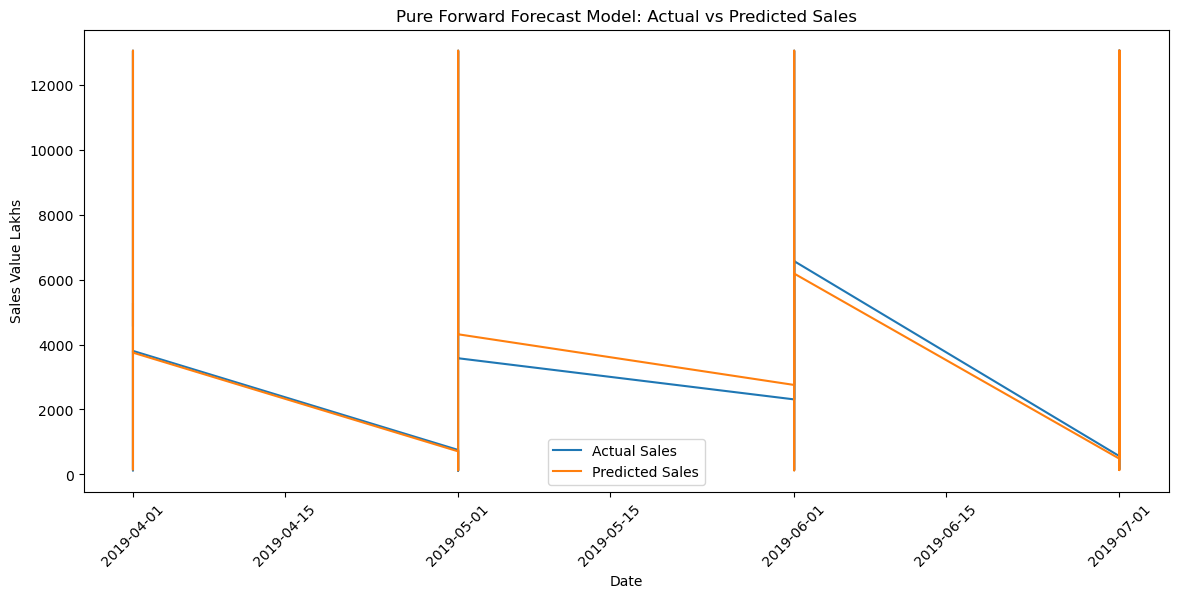

In [153]:
# PLOT ACTUAL VS PREDICTED
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(results_pure['date'], results_pure['actual_sales'], label='Actual Sales')
plt.plot(results_pure['date'], results_pure['predicted_sales'], label='Predicted Sales')
plt.title('Pure Forward Forecast Model: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales Value Lakhs')
plt.legend()
plt.xticks(rotation=45)
plt.show()

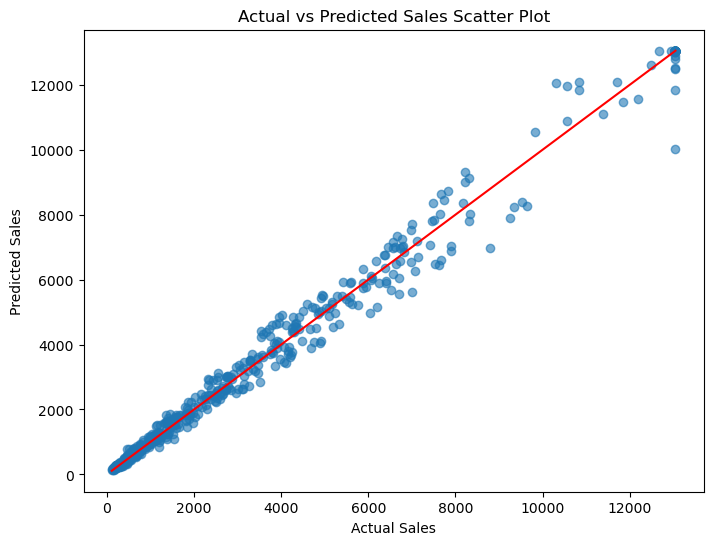

In [154]:
# SCATTER PLOT
plt.figure(figsize=(8, 6))
plt.scatter(y_test_pure, y_pred_pure, alpha=0.6)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales Scatter Plot')

min_val = min(y_test_pure.min(), y_pred_pure.min())
max_val = max(y_test_pure.max(), y_pred_pure.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.show()

In [155]:
# TOP 10 HIGHEST ERRORS
results_pure.sort_values('abs_error', ascending=False).head(10)

,date,actual_sales,predicted_sales,error,abs_error,ape
3358,2019-07-01,13049.274921,10030.323136,3018.951785,3018.951785,23.135016
3298,2019-07-01,8783.537181,6984.937339,1798.599843,1798.599843,20.476942
3064,2019-05-01,10316.380991,12063.337410,-1746.956420,1746.956420,16.933811
2934,2019-04-01,10559.301751,11967.843668,-1408.541917,1408.541917,13.339347
3352,2019-07-01,9645.371789,8272.463722,1372.908067,1372.908067,14.233853
3349,2019-07-01,6995.826173,5624.283169,1371.543004,1371.543004,19.605161
3361,2019-07-01,9256.016980,7885.388730,1370.628250,1370.628250,14.807970
3043,2019-05-01,10836.731284,12078.592298,-1241.861014,1241.861014,11.459738
3322,2019-07-01,13049.274921,11842.547889,1206.727032,1206.727032,9.247464
3378,2019-07-01,7611.848879,6447.482032,1164.366847,1164.366847,15.296768


In [156]:
# TRAIN XGBOOST MODEL
from xgboost import XGBRegressor

xgb_model = XGBRegressor( n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, objective='reg:squarederror',
    random_state=42)

xgb_model.fit(x_train_pure, y_train_pure)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [157]:
# MAKE PREDICTIONS
y_pred_xgb = xgb_model.predict(x_test_pure)

print(y_pred_xgb[:10])

[ 4736.855    5050.7646  13050.296    5394.3506   6723.302     194.82707
   269.0237  13043.974    6428.913     549.09656]


In [158]:
# EVALUATE XGBOOST
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test_pure, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_pure, y_pred_xgb))
r2_xgb = r2_score(y_test_pure, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test_pure - y_pred_xgb) / y_test_pure)) * 100

print('MAE  :', mae_xgb)
print('RMSE :', rmse_xgb)
print('R2   :', r2_xgb)
print('MAPE :', mape_xgb)


MAE  : 167.0460429701192
RMSE : 288.28417194331615
R2   : 0.9955240247789711
MAPE : 7.06609219829973


In [159]:
# MODEL COMPARISON
comparison = pd.DataFrame({
    'model': ['Random Forest', 'XGBoost'],
    'MAE': [mae_pure, mae_xgb],
    'RMSE': [rmse_pure, rmse_xgb],
    'R2': [r2_pure, r2_xgb],
    'MAPE': [mape_pure, mape_xgb]})

comparison


,model,MAE,RMSE,R2,MAPE
0,Random Forest,209.154949,368.284739,0.992695,9.003457
1,XGBoost,167.046043,288.284172,0.995524,7.066092


In [160]:
# CREATE FINAL XGBOOST RESULTS TABLE
results_xgb = test_pure[['date']].copy()
results_xgb['actual_sales'] = y_test_pure.values
results_xgb['predicted_sales'] = y_pred_xgb
results_xgb['error'] = results_xgb['actual_sales'] - results_xgb['predicted_sales']
results_xgb['abs_error'] = np.abs(results_xgb['error'])
results_xgb['ape'] = (results_xgb['abs_error'] / results_xgb['actual_sales']) * 100

results_xgb.head(10)

,date,actual_sales,predicted_sales,error,abs_error,ape
2831,2019-04-01,4587.915645,4736.854980,-148.939335,148.939335,3.246340
2832,2019-04-01,5088.284688,5050.764648,37.520039,37.520039,0.737381
2833,2019-04-01,13049.274921,13050.295898,-1.020977,1.020977,0.007824
2834,2019-04-01,4968.406264,5394.350586,-425.944322,425.944322,8.573057
2835,2019-04-01,6767.795461,6723.301758,44.493703,44.493703,0.657433
2836,2019-04-01,221.356175,194.827072,26.529103,26.529103,11.984804
2837,2019-04-01,235.927887,269.023712,-33.095825,33.095825,14.027941
2838,2019-04-01,13049.274921,13043.973633,5.301289,5.301289,0.040625
2839,2019-04-01,6391.411985,6428.913086,-37.501101,37.501101,0.586742
2840,2019-04-01,502.938748,549.096558,-46.157810,46.157810,9.177621


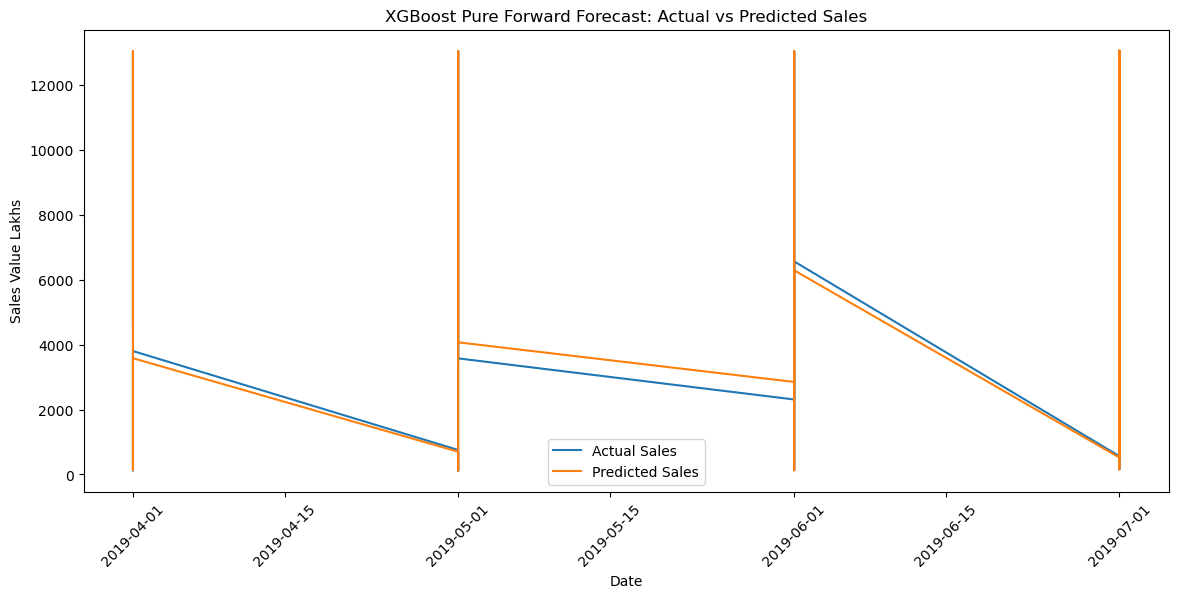

In [161]:
# PLOT ACTUAL VS PREDICTED
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(results_xgb['date'], results_xgb['actual_sales'], label='Actual Sales')
plt.plot(results_xgb['date'], results_xgb['predicted_sales'], label='Predicted Sales')
plt.title('XGBoost Pure Forward Forecast: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales Value Lakhs')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [162]:
# XGBOOST FEATURE IMPORTANCE
xgb_feature_importance = pd.DataFrame({'feature': x_train_pure.columns,'importance': xgb_model.feature_importances_}).sort_values('importance', ascending=False)

xgb_feature_importance.head(20)

,feature,importance
3,sales_lag_1,0.363526
9,sales_roll_mean_3,0.306910
6,volume_lag_1,0.272642
10,volume_roll_mean_3,0.023298
4,sales_lag_2,0.010145
15,pdo_kgs_outlier_flag,0.002540
20,stock_weight_tonnes_outlier_flag,0.002242
5,sales_lag_3,0.001445
19,sales_value_lakhs_outlier_flag,0.001013
61,segment_Delhi + NCR,0.000983


In [163]:
# SAVE PREDICTIONS
#results_xgb.to_csv(r'C:\Users\HP\Desktop\Bishal_\ML\ML PROJECTS\CHOCOLATE_SALES_PREDICTION\xgboost_sales_forecast_results.csv', index=False)

# SAVE MODEL COMPARISON
#comparison.to_csv(r'C:\Users\HP\Desktop\Bishal_\ML\ML PROJECTS\CHOCOLATE_SALES_PREDICTION\model_comparison.csv', index=False)


# FINAL PROJECT CONCLUSION

In [164]:
#Final model: XGBoost Regressor

##Forecast type: Pure Forward Forecast

#Target: Next Month Sales Value (Lakhs)
#Final performance:
#MAE = 167.05
#RMSE = 288.28
#R2 = 0.9955
#MAPE = 7.07%

In [165]:
#Key Business Insights

#Recent sales trend was the strongest predictor of future sales.
#sales_lag_1 and sales_roll_mean_3 were the most important drivers.
#Recent volume behavior also improved forecasting accuracy.
#The model performed very well overall, but larger errors appeared during sudden peak-demand months.
#XGBoost handled extreme sales variation better than Random Forest.